# Мульти-модельный ансамбль и Микро-тюнинг

Текущий рекордсмен лидерборда: Ортогональный бленд CatBoost v4a (90%) + RNN v2 (10%) со скором 1.65935.

Задачи:
- **Micro-tuning:** Проверка экстремальных весов (93/7, 95/5, 97/3) для поиска абсолютного минимума параболы ошибки.
- **Внедрение LightGBM v4:** Бленд исправленного LightGBM с чемпионом.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from scipy.stats import spearmanr
from itertools import product
import matplotlib.pyplot as plt

PROCESSED_DIR = Path("../data/processed")

## Загрузка всех моделей

In [2]:
models = {}

model_files = {
    'catboost_v3': 'catboost_v3_submission.csv',
    'lgbm_v3': 'lgbm_v3_submission.csv',
    'rnn_v3': 'rnn_v3_submission.csv',
    'catboost_v2': 'catboost_v2_submission.csv',
    'rnn_v2': 'rnn_v2_submission.csv',
}

for name, filename in model_files.items():
    path = PROCESSED_DIR / filename
    if path.exists():
        df = pd.read_csv(path)
        models[name] = df
        print(f"✅ {name}: mean={df['predict'].mean():.2f}, median={df['predict'].median():.2f}")
    else:
        print(f"❌ {name}: файл не найден")

ref_ids = list(list(models.values())[0]['user_id'])
for name, df in models.items():
    assert list(df['user_id']) == ref_ids, f"{name}: user_id не совпадают!"
print(f"\nВсего моделей: {len(models)}, пользователей: {len(ref_ids):,}")

✅ catboost_v3: mean=42.87, median=8.54
✅ lgbm_v3: mean=43.04, median=8.54
✅ rnn_v3: mean=42.19, median=8.83
✅ catboost_v2: mean=42.75, median=8.53
✅ rnn_v2: mean=39.45, median=8.44

Всего моделей: 5, пользователей: 250,000


## Корреляционная матрица

In [3]:
model_names = list(models.keys())
n = len(model_names)

print("Матрица корреляций Пирсона:")
print(f"{'':>15}", end="")
for name in model_names:
    print(f"{name:>15}", end="")
print()

for i, name_i in enumerate(model_names):
    print(f"{name_i:>15}", end="")
    for j, name_j in enumerate(model_names):
        corr = np.corrcoef(models[name_i]['predict'], models[name_j]['predict'])[0, 1]
        print(f"{corr:>15.4f}", end="")
    print()

Матрица корреляций Пирсона:
                   catboost_v3        lgbm_v3         rnn_v3    catboost_v2         rnn_v2
    catboost_v3         1.0000         0.9927         0.9327         0.9736         0.9439
        lgbm_v3         0.9927         1.0000         0.9337         0.9721         0.9460
         rnn_v3         0.9327         0.9337         1.0000         0.9182         0.9709
    catboost_v2         0.9736         0.9721         0.9182         1.0000         0.9354
         rnn_v2         0.9439         0.9460         0.9709         0.9354         1.0000


## Генерация блендов

### 2-model blend

In [4]:
# 2-model: CatBoost + RNN
if 'catboost_v3' in models and 'rnn_v3' in models:
    cb = models['catboost_v3']
    rnn = models['rnn_v3']
    
    print("CatBoost v3 + RNN v3:")
    for alpha in [0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9]:
        blend = (alpha * cb['predict'] + (1 - alpha) * rnn['predict']).clip(lower=0)
        fname = f"blend_cb{int(alpha*100)}_rnn{int((1-alpha)*100)}.csv"
        pd.DataFrame({'user_id': cb['user_id'], 'predict': blend}).to_csv(PROCESSED_DIR / fname, index=False)
        print(f"  alpha={alpha:.2f} | mean={blend.mean():.2f} | saved: {fname}")

CatBoost v3 + RNN v3:
  alpha=0.60 | mean=42.60 | saved: blend_cb60_rnn40.csv
  alpha=0.65 | mean=42.63 | saved: blend_cb65_rnn35.csv
  alpha=0.70 | mean=42.67 | saved: blend_cb70_rnn30.csv
  alpha=0.75 | mean=42.70 | saved: blend_cb75_rnn25.csv
  alpha=0.80 | mean=42.74 | saved: blend_cb80_rnn19.csv
  alpha=0.85 | mean=42.77 | saved: blend_cb85_rnn15.csv
  alpha=0.90 | mean=42.80 | saved: blend_cb90_rnn9.csv


### 3-model blend (CatBoost + LightGBM + RNN)

In [5]:
if all(m in models for m in ['catboost_v3', 'lgbm_v3', 'rnn_v3']):
    cb = models['catboost_v3']['predict']
    lgbm_pred = models['lgbm_v3']['predict']
    rnn = models['rnn_v3']['predict']
    user_ids = models['catboost_v3']['user_id']
    
    print("3-model blends (CatBoost + LightGBM + RNN):")
    print(f"{'Веса (CB/LG/RNN)':<25} {'mean':>8}")
    
    weight_combos = [
        (0.4, 0.4, 0.2),
        (0.5, 0.3, 0.2),
        (0.3, 0.5, 0.2),
        (0.4, 0.3, 0.3),
        (0.3, 0.4, 0.3),
        (0.35, 0.35, 0.3),
        (0.45, 0.35, 0.2),
        (0.35, 0.45, 0.2),
    ]
    
    for w_cb, w_lg, w_rnn in weight_combos:
        blend = (w_cb * cb + w_lg * lgbm_pred + w_rnn * rnn).clip(lower=0)
        fname = f"blend3_cb{int(w_cb*100)}_lg{int(w_lg*100)}_rnn{int(w_rnn*100)}.csv"
        pd.DataFrame({'user_id': user_ids, 'predict': blend}).to_csv(PROCESSED_DIR / fname, index=False)
        print(f"  {w_cb:.2f}/{w_lg:.2f}/{w_rnn:.2f}      | {blend.mean():>8.2f} | {fname}")
else:
    missing = [m for m in ['catboost_v3', 'lgbm_v3', 'rnn_v3'] if m not in models]
    print(f"3-model blend невозможен, не хватает: {missing}")

3-model blends (CatBoost + LightGBM + RNN):
Веса (CB/LG/RNN)              mean
  0.40/0.40/0.20      |    42.80 | blend3_cb40_lg40_rnn20.csv
  0.50/0.30/0.20      |    42.78 | blend3_cb50_lg30_rnn20.csv
  0.30/0.50/0.20      |    42.82 | blend3_cb30_lg50_rnn20.csv
  0.40/0.30/0.30      |    42.72 | blend3_cb40_lg30_rnn30.csv
  0.30/0.40/0.30      |    42.73 | blend3_cb30_lg40_rnn30.csv
  0.35/0.35/0.30      |    42.72 | blend3_cb35_lg35_rnn30.csv
  0.45/0.35/0.20      |    42.79 | blend3_cb45_lg35_rnn20.csv
  0.35/0.45/0.20      |    42.81 | blend3_cb35_lg45_rnn20.csv


## Визуализация

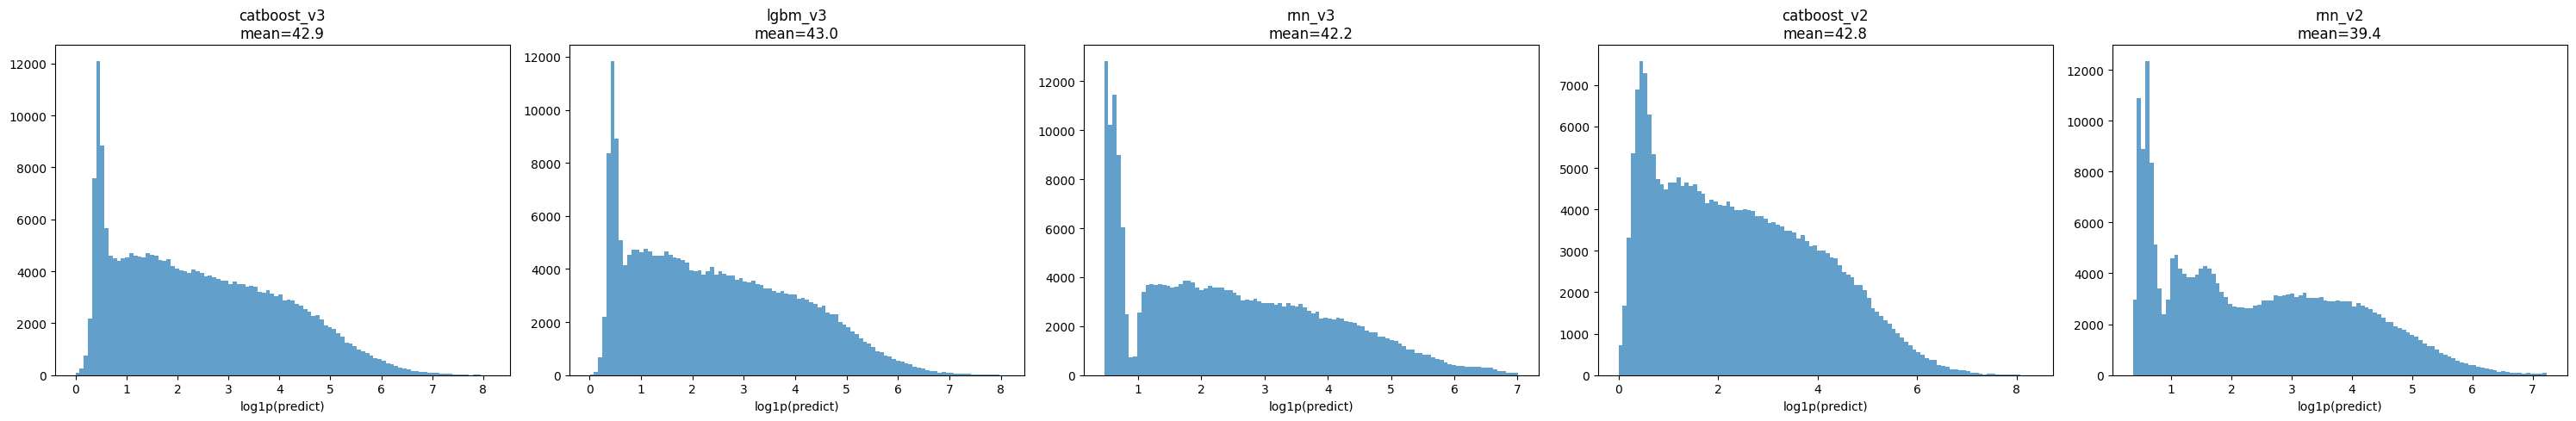

In [6]:
n_models = len(models)
if n_models >= 2:
    fig, axes = plt.subplots(1, n_models, figsize=(6*n_models, 5))
    if n_models == 1:
        axes = [axes]
    
    for i, (name, df) in enumerate(models.items()):
        axes[i].hist(np.log1p(df['predict']), bins=100, alpha=0.7)
        axes[i].set_title(f'{name}\nmean={df["predict"].mean():.1f}')
        axes[i].set_xlabel('log1p(predict)')
    
    plt.tight_layout()
    plt.show()

# Предпоследний блендинг(уже в лидерборде)

In [ ]:
import pandas as pd
from pathlib import Path

PROCESSED = Path("../data/processed")

v4a = pd.read_csv(PROCESSED / "catboost_v4a_baseline_submission.csv")
rnn = pd.read_csv(PROCESSED / "rnn_v2_submission.csv")
lgbm = pd.read_csv(PROCESSED / "lgbm_v4_submission.csv")

def save_blend(preds, filename):
    sub = v4a.copy()
    sub["predict"] = preds
    sub.to_csv(PROCESSED / filename, index=False)
    print(f"Готово: {filename:25s} | mean = {sub['predict'].mean():.4f}")

print("Генерация финальных сабмитов...")

save_blend(0.85 * v4a["predict"] + 0.15 * rnn["predict"], "blend_ortho_85_15.csv")
save_blend(0.90 * v4a["predict"] + 0.10 * rnn["predict"], "blend_ortho_90_10.csv")

save_blend(0.60 * v4a["predict"] + 0.40 * lgbm["predict"], "blend_v4a60_lgbm40.csv")

Генерация финальных сабмитов...
Готово: blend_ortho_85_15.csv     | mean = 35.9660
Готово: blend_ortho_90_10.csv     | mean = 35.7612
Готово: blend_v4a60_lgbm40.csv    | mean = 35.3520


In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path

PROCESSED_DIR = Path("../data/processed")

print("Загрузка моделей для финальных сабмитов...")

cb_v4a = pd.read_csv(PROCESSED_DIR / "catboost_v4a_baseline_submission.csv").sort_values('user_id').reset_index(drop=True)
rnn_v2 = pd.read_csv(PROCESSED_DIR / "rnn_v2_submission.csv").sort_values('user_id').reset_index(drop=True)
lgbm_v4 = pd.read_csv(PROCESSED_DIR / "lgbm_v4_submission.csv").sort_values('user_id').reset_index(drop=True)

assert (cb_v4a['user_id'] == rnn_v2['user_id']).all(), "Ошибка в сортировке user_id (RNN)"
assert (cb_v4a['user_id'] == lgbm_v4['user_id']).all(), "Ошибка в сортировке user_id (LGBM)"

def save_final_blend(preds, filename):
    sub = cb_v4a[['user_id']].copy()
    sub['predict'] = np.clip(preds, 0, None)
    sub.to_csv(PROCESSED_DIR / filename, index=False)
    print(f"Готово: {filename:25s} | mean = {sub['predict'].mean():.4f}")

print("\n--- Стратегия: Ортогональные бленды (CatBoost v4a + RNN v2) ---")
save_final_blend(0.85 * cb_v4a['predict'] + 0.15 * rnn_v2['predict'], "blend_ortho_85_15.csv")
save_final_blend(0.90 * cb_v4a['predict'] + 0.10 * rnn_v2['predict'], "blend_ortho_90_10.csv")

print("\n--- Стратегия: Мощный Бустинг-бленд (CatBoost v4a + LightGBM v4) ---")
save_final_blend(0.60 * cb_v4a['predict'] + 0.40 * lgbm_v4['predict'], "blend_v4a60_lgbm40.csv")

Загрузка моделей для финальных сабмитов...

--- Стратегия: Ортогональные бленды (CatBoost v4a + RNN v2) ---
Готово: blend_ortho_85_15.csv     | mean = 35.9660
Готово: blend_ortho_90_10.csv     | mean = 35.7612

--- Стратегия: Мощный Бустинг-бленд (CatBoost v4a + LightGBM v4) ---
Готово: blend_v4a60_lgbm40.csv    | mean = 35.3520


# Последняя актуальная ячейка кода для блендинга

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path

PROCESSED_DIR = Path("../data/processed")

print("Загрузка моделей для финальных блендов...")
cb_v4b = pd.read_csv(PROCESSED_DIR / "catboost_v4b_seed_avg.csv").sort_values('user_id').reset_index(drop=True)
rnn_v2 = pd.read_csv(PROCESSED_DIR / "rnn_v2_submission.csv").sort_values('user_id').reset_index(drop=True)

assert (cb_v4b['user_id'] == rnn_v2['user_id']).all(), "Ошибка в сортировке user_id!"

def save_final_blend(alpha, filename):
    sub = cb_v4b[['user_id']].copy()
    preds = alpha * cb_v4b['predict'] + (1.0 - alpha) * rnn_v2['predict']
    sub['predict'] = np.clip(preds, 0, None)
    sub.to_csv(PROCESSED_DIR / filename, index=False)
    print(f"Готово: {filename:30s} | mean = {sub['predict'].mean():.4f}")

print("\n--- Генерация финальных блендов (v4b + v2) ---")
save_final_blend(0.90, "blend_v4b_ortho_90_10.csv")
save_final_blend(0.95, "blend_v4b_ortho_95_05.csv")
save_final_blend(0.85, "blend_v4b_ortho_85_15.csv")

Загрузка моделей для сегодняшних блендов...

--- Генерация финальных попыток на сегодня ---
Готово: blend_v4a_ortho_90_10.csv | mean = 35.1095
Готово: blend_v4a_ortho_95_05.csv | mean = 35.2305
